# Injury Risk EDA — Correlation & Outlier Analysis
**Dataset:** `cleaned_player_data_performance_model_outliers_removed.csv`  
**Target Column:** `injury_risk` (0 = Safe, 1 = Injured)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv("cleaned_player_data_performance_model_outliers_removed.csv")
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Shape: {df.shape}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
df.head()

Shape: (8714, 19)
Numeric columns (17): ['overall_rating', 'potential', 'ball_control', 'dribbling', 'stamina', 'reactions', 'balance', 'strength', 'acceleration', 'age', 'fatigue_index', 'matches_last_7_days', 'minutes_played', 'recovery_time', 'previous_injury_count', 'training_load', 'injury_risk']


,overall_rating,potential,ball_control,dribbling,stamina,reactions,balance,strength,acceleration,age,attacking_work_rate,defensive_work_rate,fatigue_index,matches_last_7_days,minutes_played,recovery_time,previous_injury_count,training_load,injury_risk
0,67.0,71.0,49.0,51.0,54.0,47.0,65.0,76.0,60.0,34.036961,medium,medium,65.9,1,1722,46.4,1,4.8,0
1,74.0,76.0,71.0,73.0,79.0,67.0,90.0,56.0,79.0,36.243669,high,medium,40.7,1,2566,42.0,1,6.6,0
2,65.0,67.0,67.0,66.0,66.0,51.0,92.0,71.0,77.0,34.836413,medium,medium,47.8,2,1815,43.1,2,3.1,0
3,77.0,77.0,79.0,78.0,75.0,80.0,72.0,65.0,75.0,39.523614,medium,medium,48.0,3,3192,38.8,3,8.3,1
4,61.0,74.0,63.0,54.0,68.0,61.0,80.0,59.0,69.0,30.119097,medium,high,50.9,3,2029,47.2,1,4.8,0


---
## 1. Target Variable Distribution

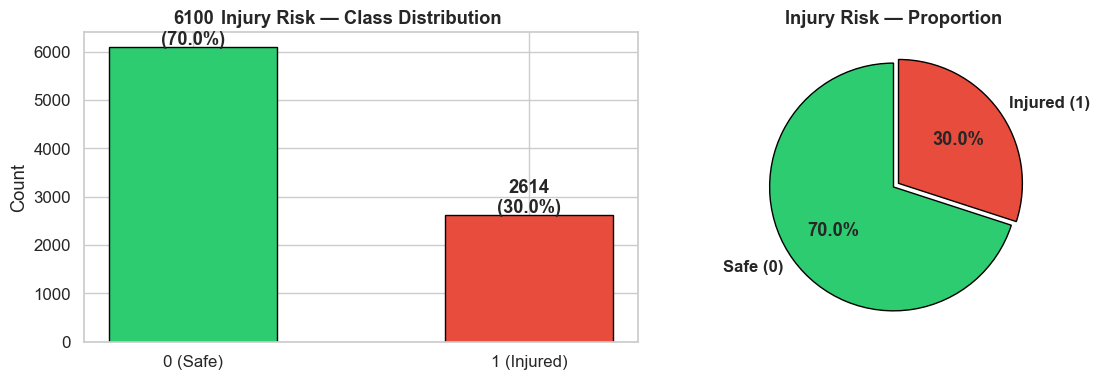

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df["injury_risk"].value_counts().sort_index()
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["0 (Safe)", "1 (Injured)"], counts.values, color=colors, edgecolor="black", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
axes[0].set_title("Injury Risk — Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(counts.values, labels=["Safe (0)", "Injured (1)"], colors=colors,
            autopct="%1.1f%%", startangle=90, explode=(0, 0.05),
            textprops={"fontweight": "bold"}, wedgeprops={"edgecolor": "black"})
axes[1].set_title("Injury Risk — Proportion", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 2. Correlation Heatmap — All Numeric Features

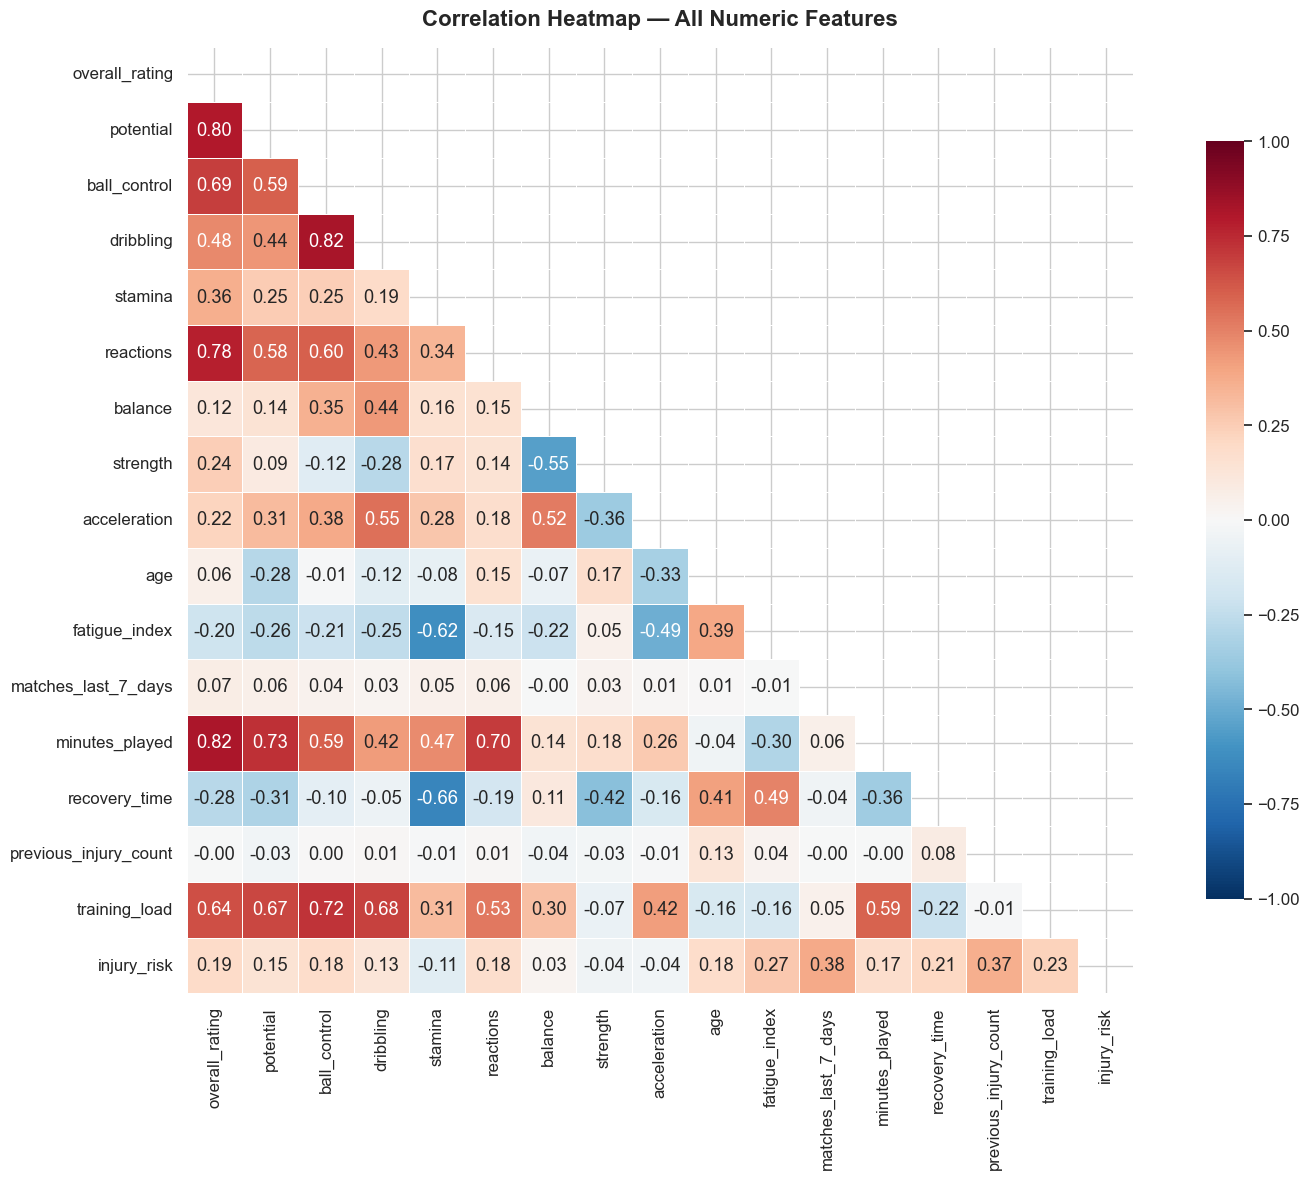

In [3]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — All Numeric Features", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

---
## 3. Correlation with Target (`injury_risk`) — Bar Chart

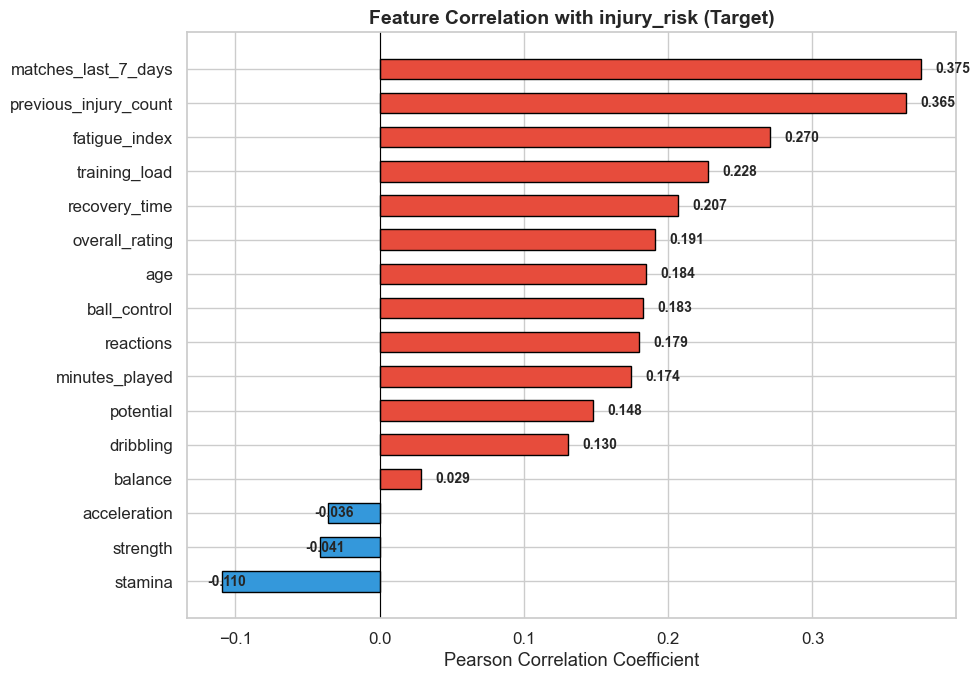

In [4]:
target_corr = corr["injury_risk"].drop("injury_risk").sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="black", height=0.6)

for bar, val in zip(bars, target_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontweight="bold", fontsize=10)

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation Coefficient")
ax.set_title("Feature Correlation with injury_risk (Target)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Feature Distribution by Injury Risk — Violin Plots

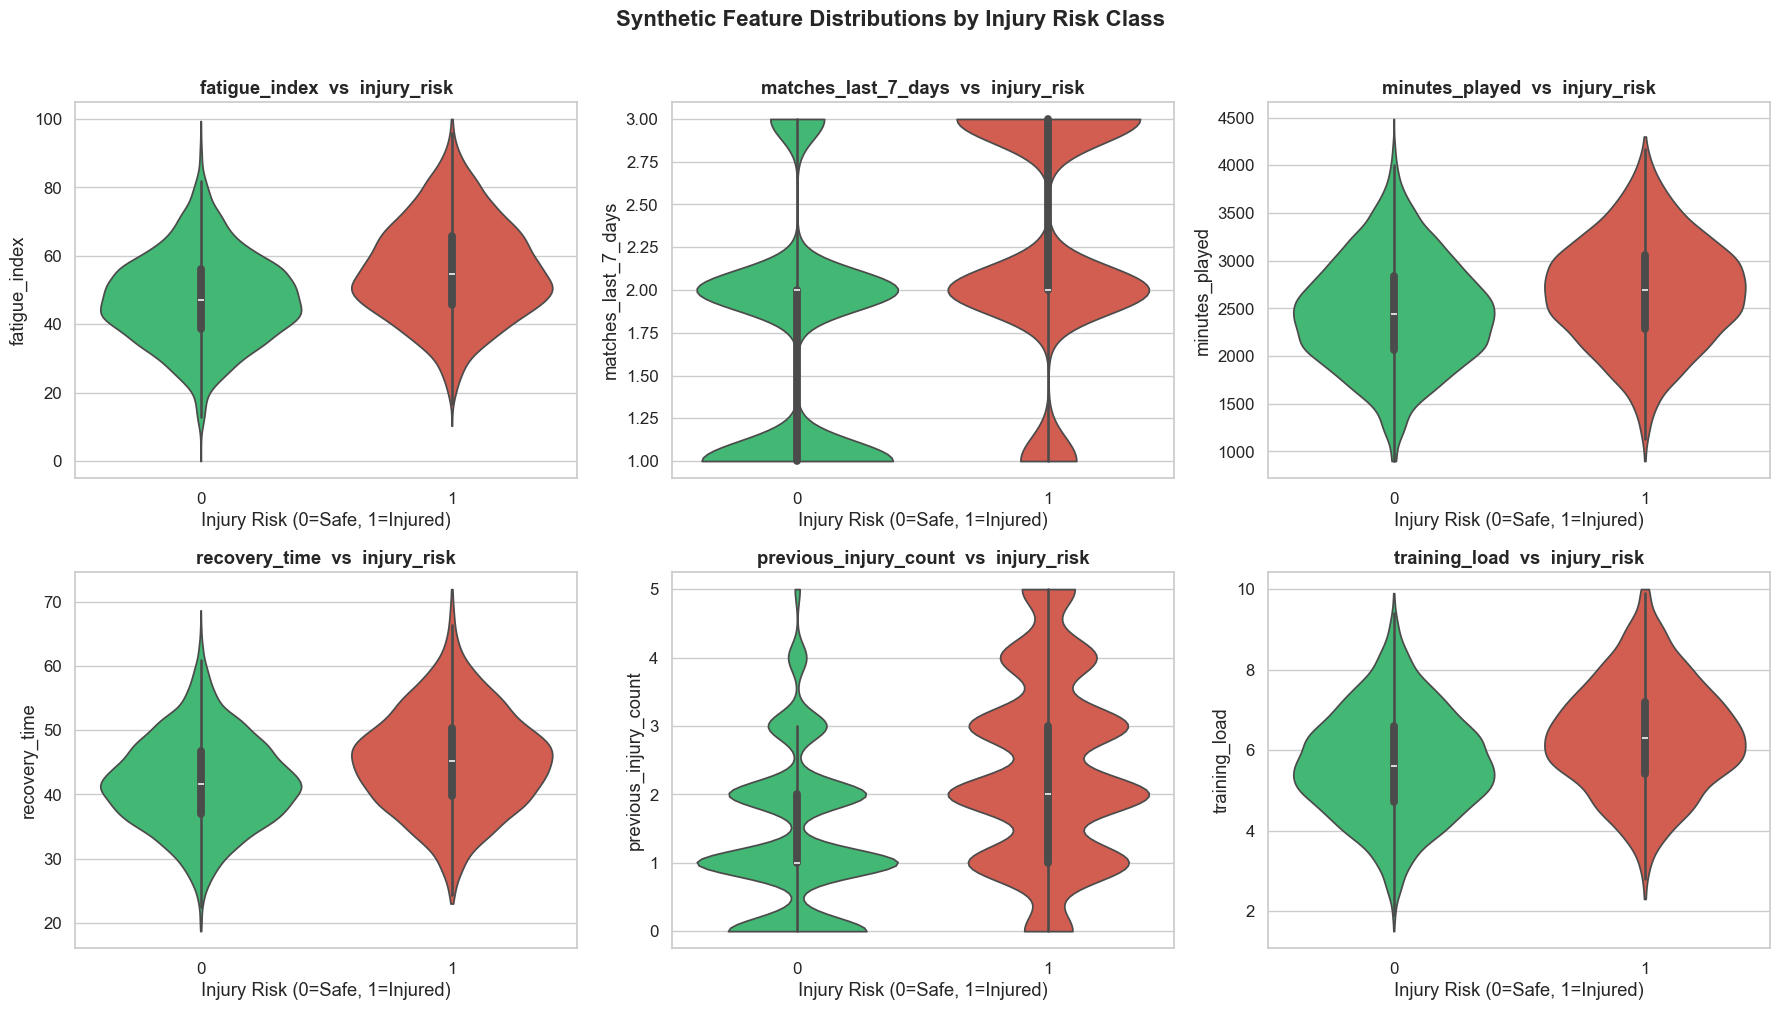

In [5]:
# Synthetic injury columns — show distribution split by target
injury_features = ["fatigue_index", "matches_last_7_days", "minutes_played",
                   "recovery_time", "previous_injury_count", "training_load"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(injury_features):
    sns.violinplot(x="injury_risk", y=col, data=df, ax=axes[i],
                   palette=["#2ecc71", "#e74c3c"], inner="box", cut=0)
    axes[i].set_title(f"{col}  vs  injury_risk", fontweight="bold")
    axes[i].set_xlabel("Injury Risk (0=Safe, 1=Injured)")

plt.suptitle("Synthetic Feature Distributions by Injury Risk Class", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Original Player Features — Distribution by Injury Risk

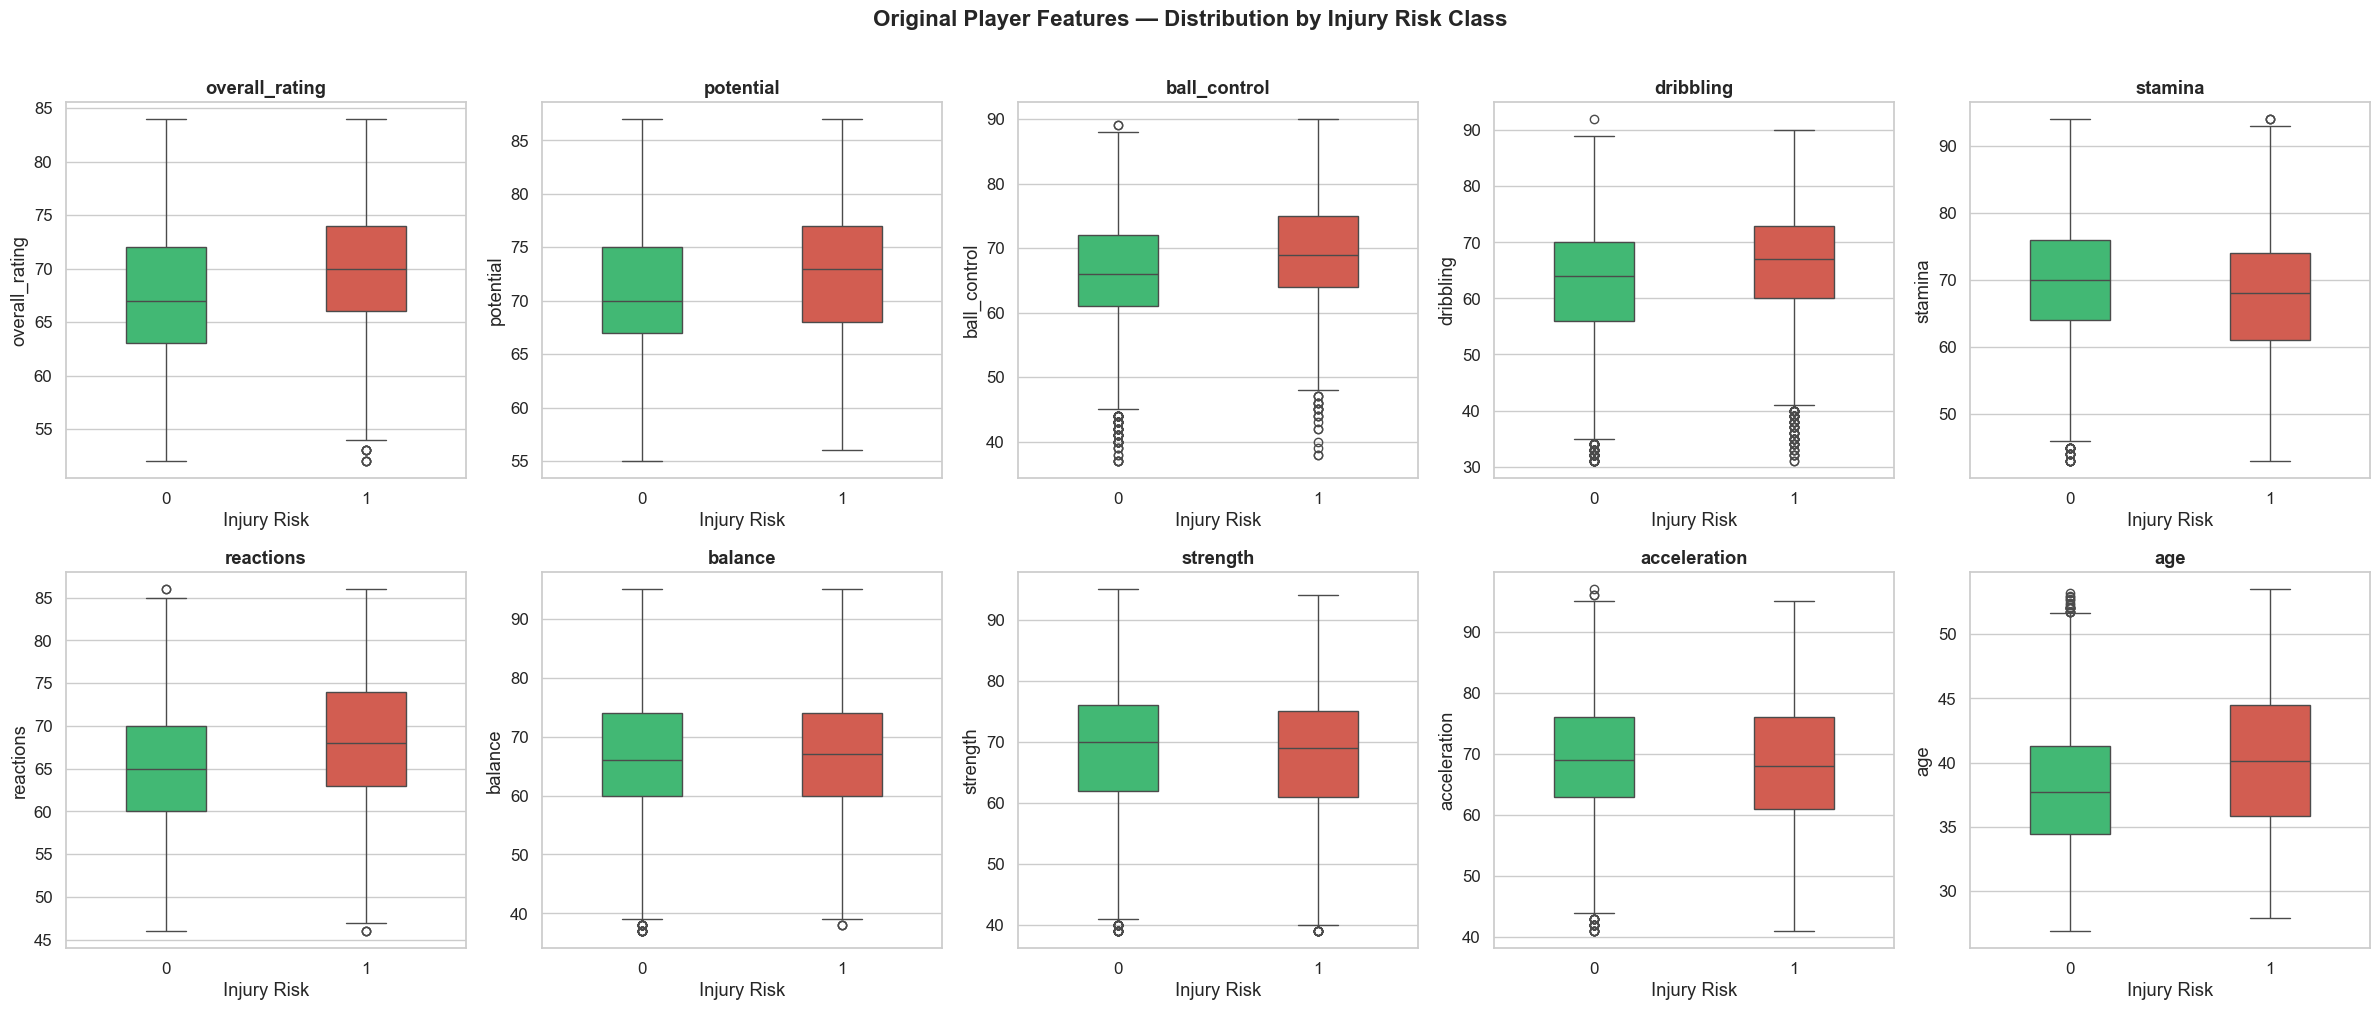

In [6]:
# Original player attribute columns
original_features = ["overall_rating", "potential", "ball_control", "dribbling",
                     "stamina", "reactions", "balance", "strength", "acceleration", "age"]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.ravel()

for i, col in enumerate(original_features):
    sns.boxplot(x="injury_risk", y=col, data=df, ax=axes[i],
                palette=["#2ecc71", "#e74c3c"], width=0.4)
    axes[i].set_title(f"{col}", fontweight="bold")
    axes[i].set_xlabel("Injury Risk")

plt.suptitle("Original Player Features — Distribution by Injury Risk Class",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Outlier Detection — Boxplots with IQR Boundaries (All Numeric Features)

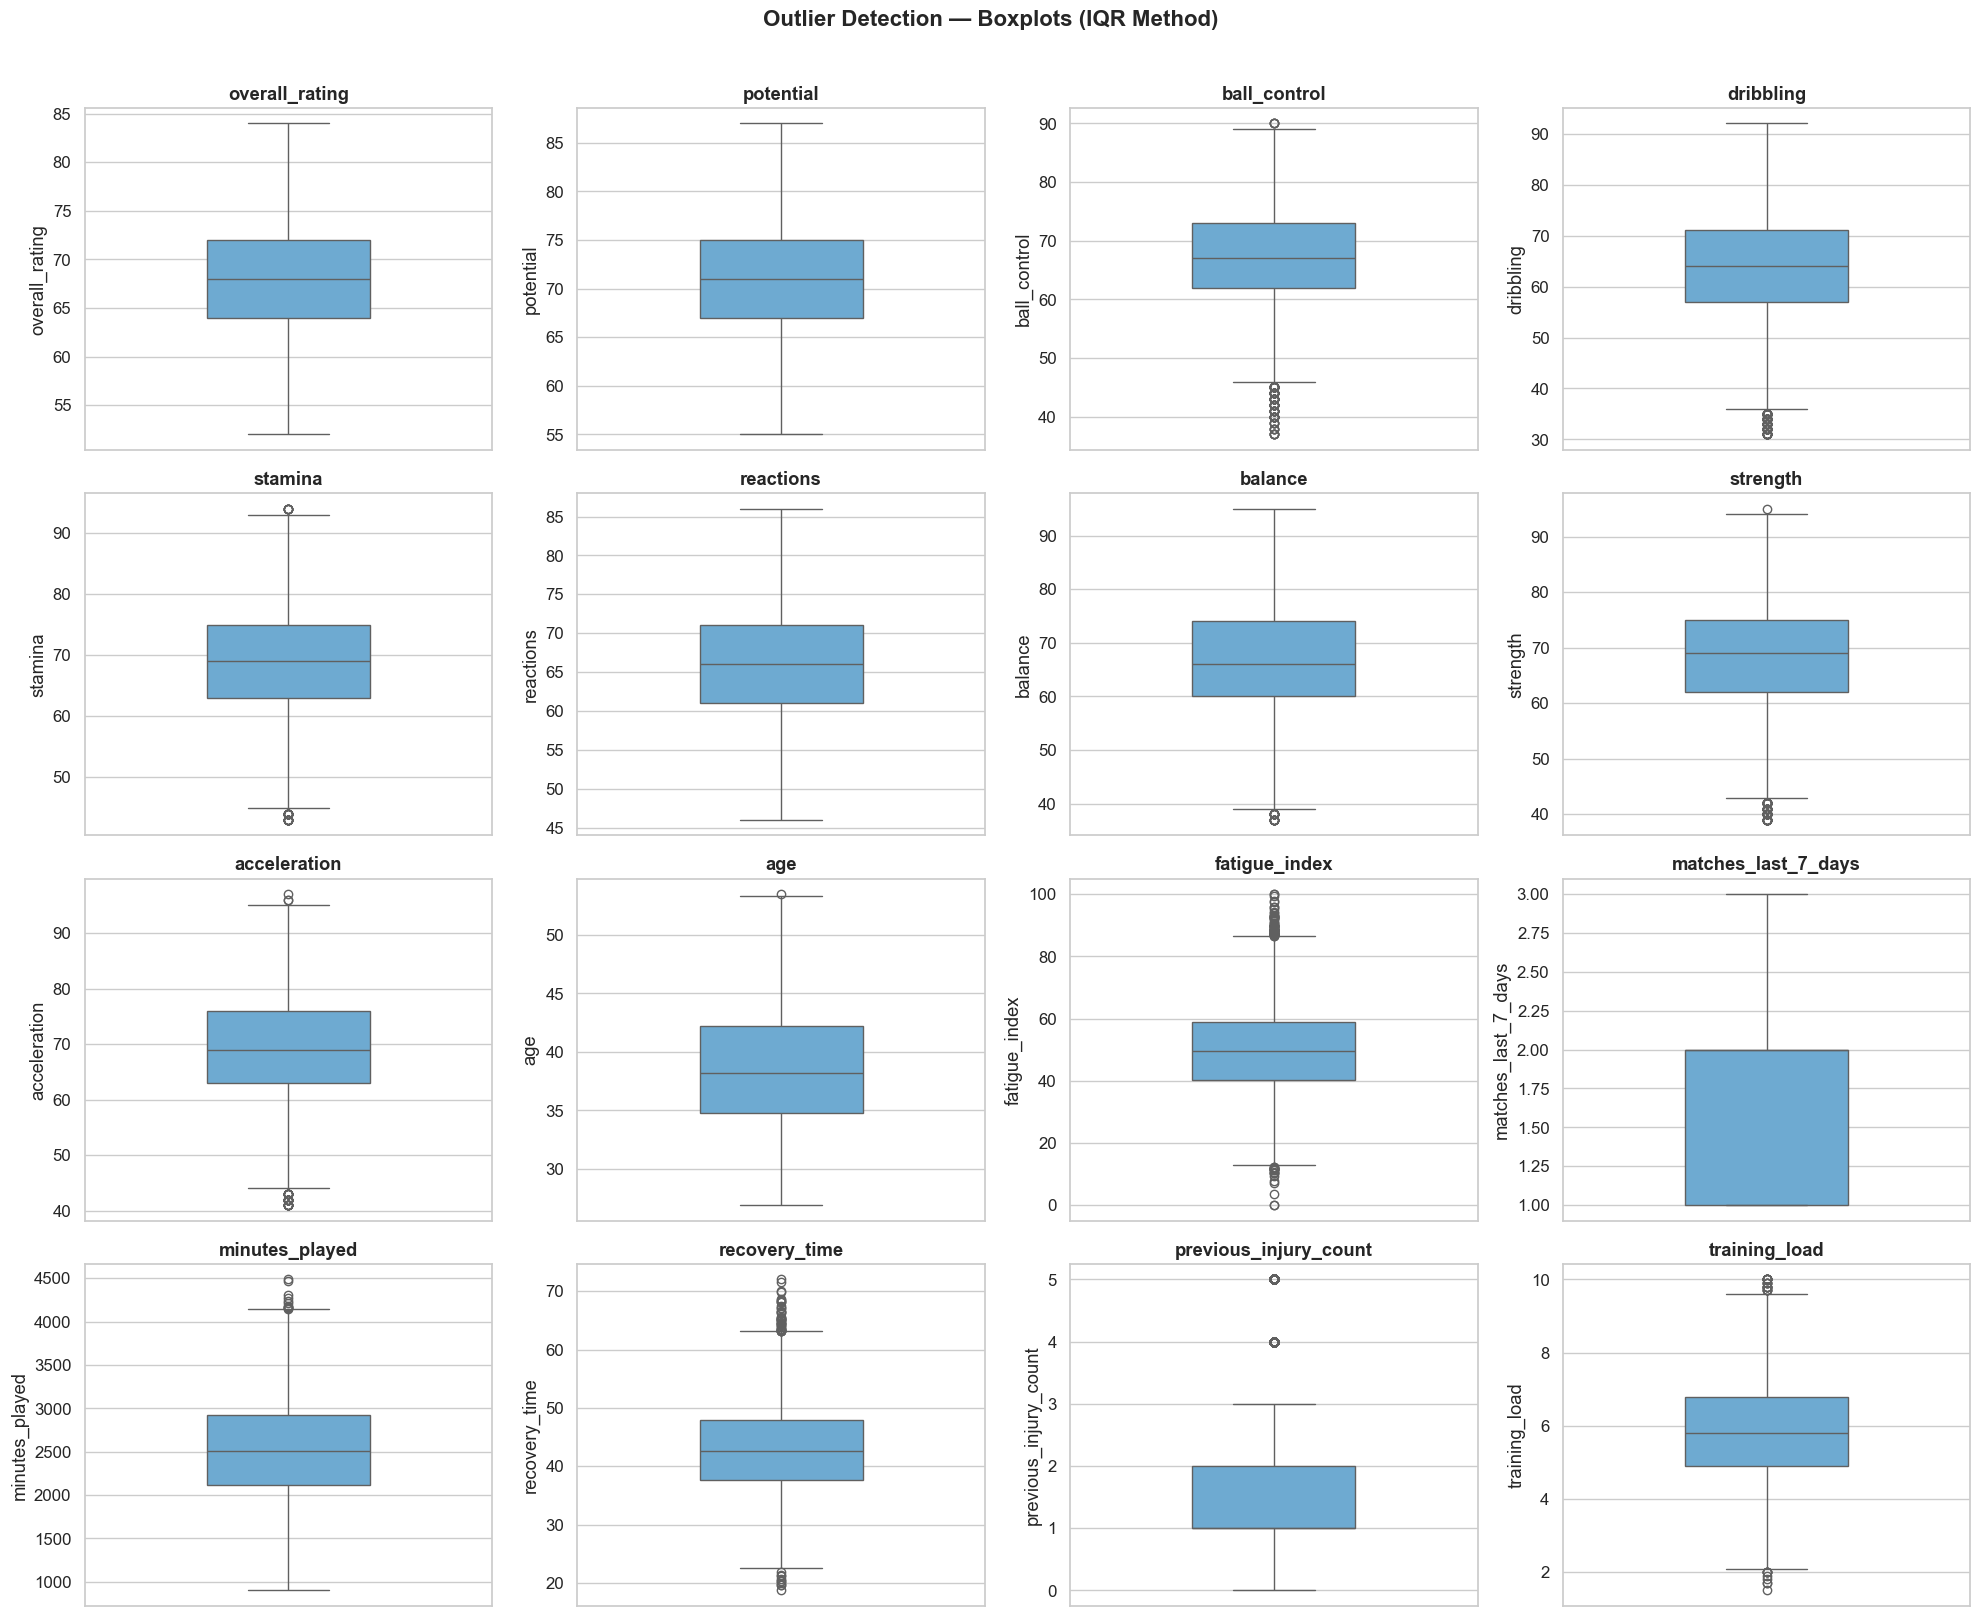

In [7]:
# Boxplots for every numeric column to visually check outliers
features = [c for c in numeric_cols if c != "injury_risk"]
n_features = len(features)
n_cols_grid = 4
n_rows_grid = (n_features + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 4))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="#5dade2", width=0.4)
    axes[i].set_title(col, fontweight="bold")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection — Boxplots (IQR Method)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Outlier Count Summary — IQR Method (Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [8]:
# Quantify outliers per column using IQR rule
outlier_summary = []
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier Count", ascending=False)
outlier_df.style.background_gradient(subset=["Outlier Count", "Outlier %"], cmap="Reds")

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
14,previous_injury_count,1.000000,2.000000,1.000000,-0.500000,3.500000,795,9.120000
3,dribbling,57.000000,71.000000,14.000000,36.000000,92.000000,147,1.690000
2,ball_control,62.000000,73.000000,11.000000,45.500000,89.500000,113,1.300000
7,strength,62.000000,75.000000,13.000000,42.500000,94.500000,108,1.240000
10,fatigue_index,40.300000,58.800000,18.500000,12.550000,86.550000,85,0.980000
13,recovery_time,37.700000,47.900000,10.200000,22.400000,63.200000,51,0.590000
8,acceleration,63.000000,76.000000,13.000000,43.500000,95.500000,41,0.470000
4,stamina,63.000000,75.000000,12.000000,45.000000,93.000000,39,0.450000
15,training_load,4.900000,6.800000,1.900000,2.050000,9.650000,34,0.390000
6,balance,60.000000,74.000000,14.000000,39.000000,95.000000,25,0.290000


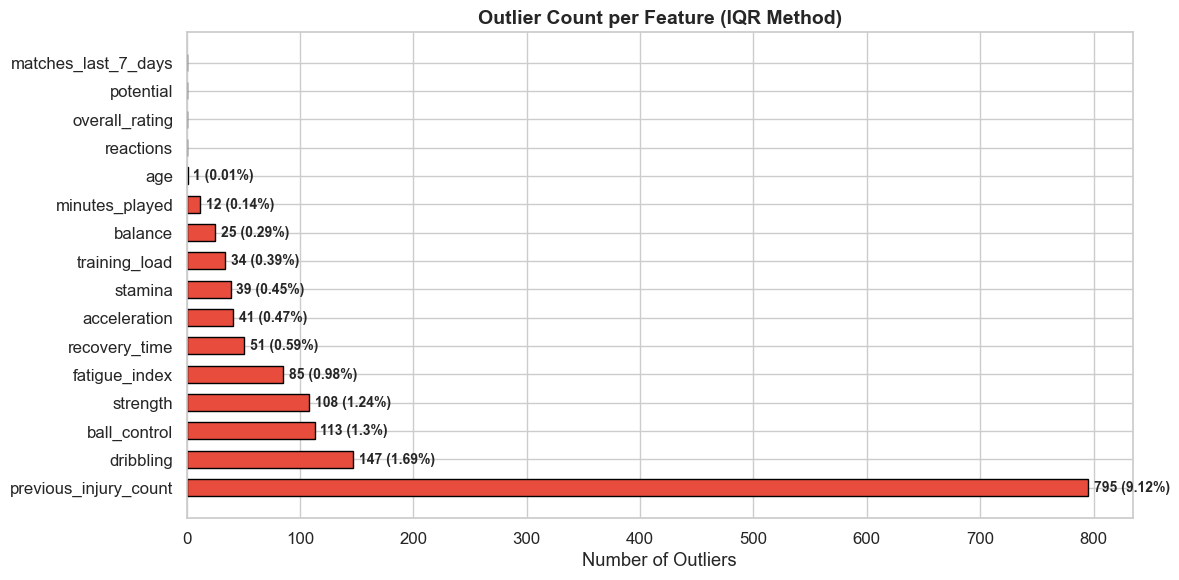

In [9]:
# Bar chart of outlier counts per feature
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(outlier_df["Feature"], outlier_df["Outlier Count"],
               color=["#e74c3c" if v > 0 else "#2ecc71" for v in outlier_df["Outlier Count"]],
               edgecolor="black", height=0.6)

for bar, val, pct in zip(bars, outlier_df["Outlier Count"], outlier_df["Outlier %"]):
    if val > 0:
        ax.text(val + 5, bar.get_y() + bar.get_height()/2,
                f"{val} ({pct}%)", va="center", fontweight="bold", fontsize=10)

ax.set_xlabel("Number of Outliers")
ax.set_title("Outlier Count per Feature (IQR Method)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Histograms with KDE — Distribution Shape Check

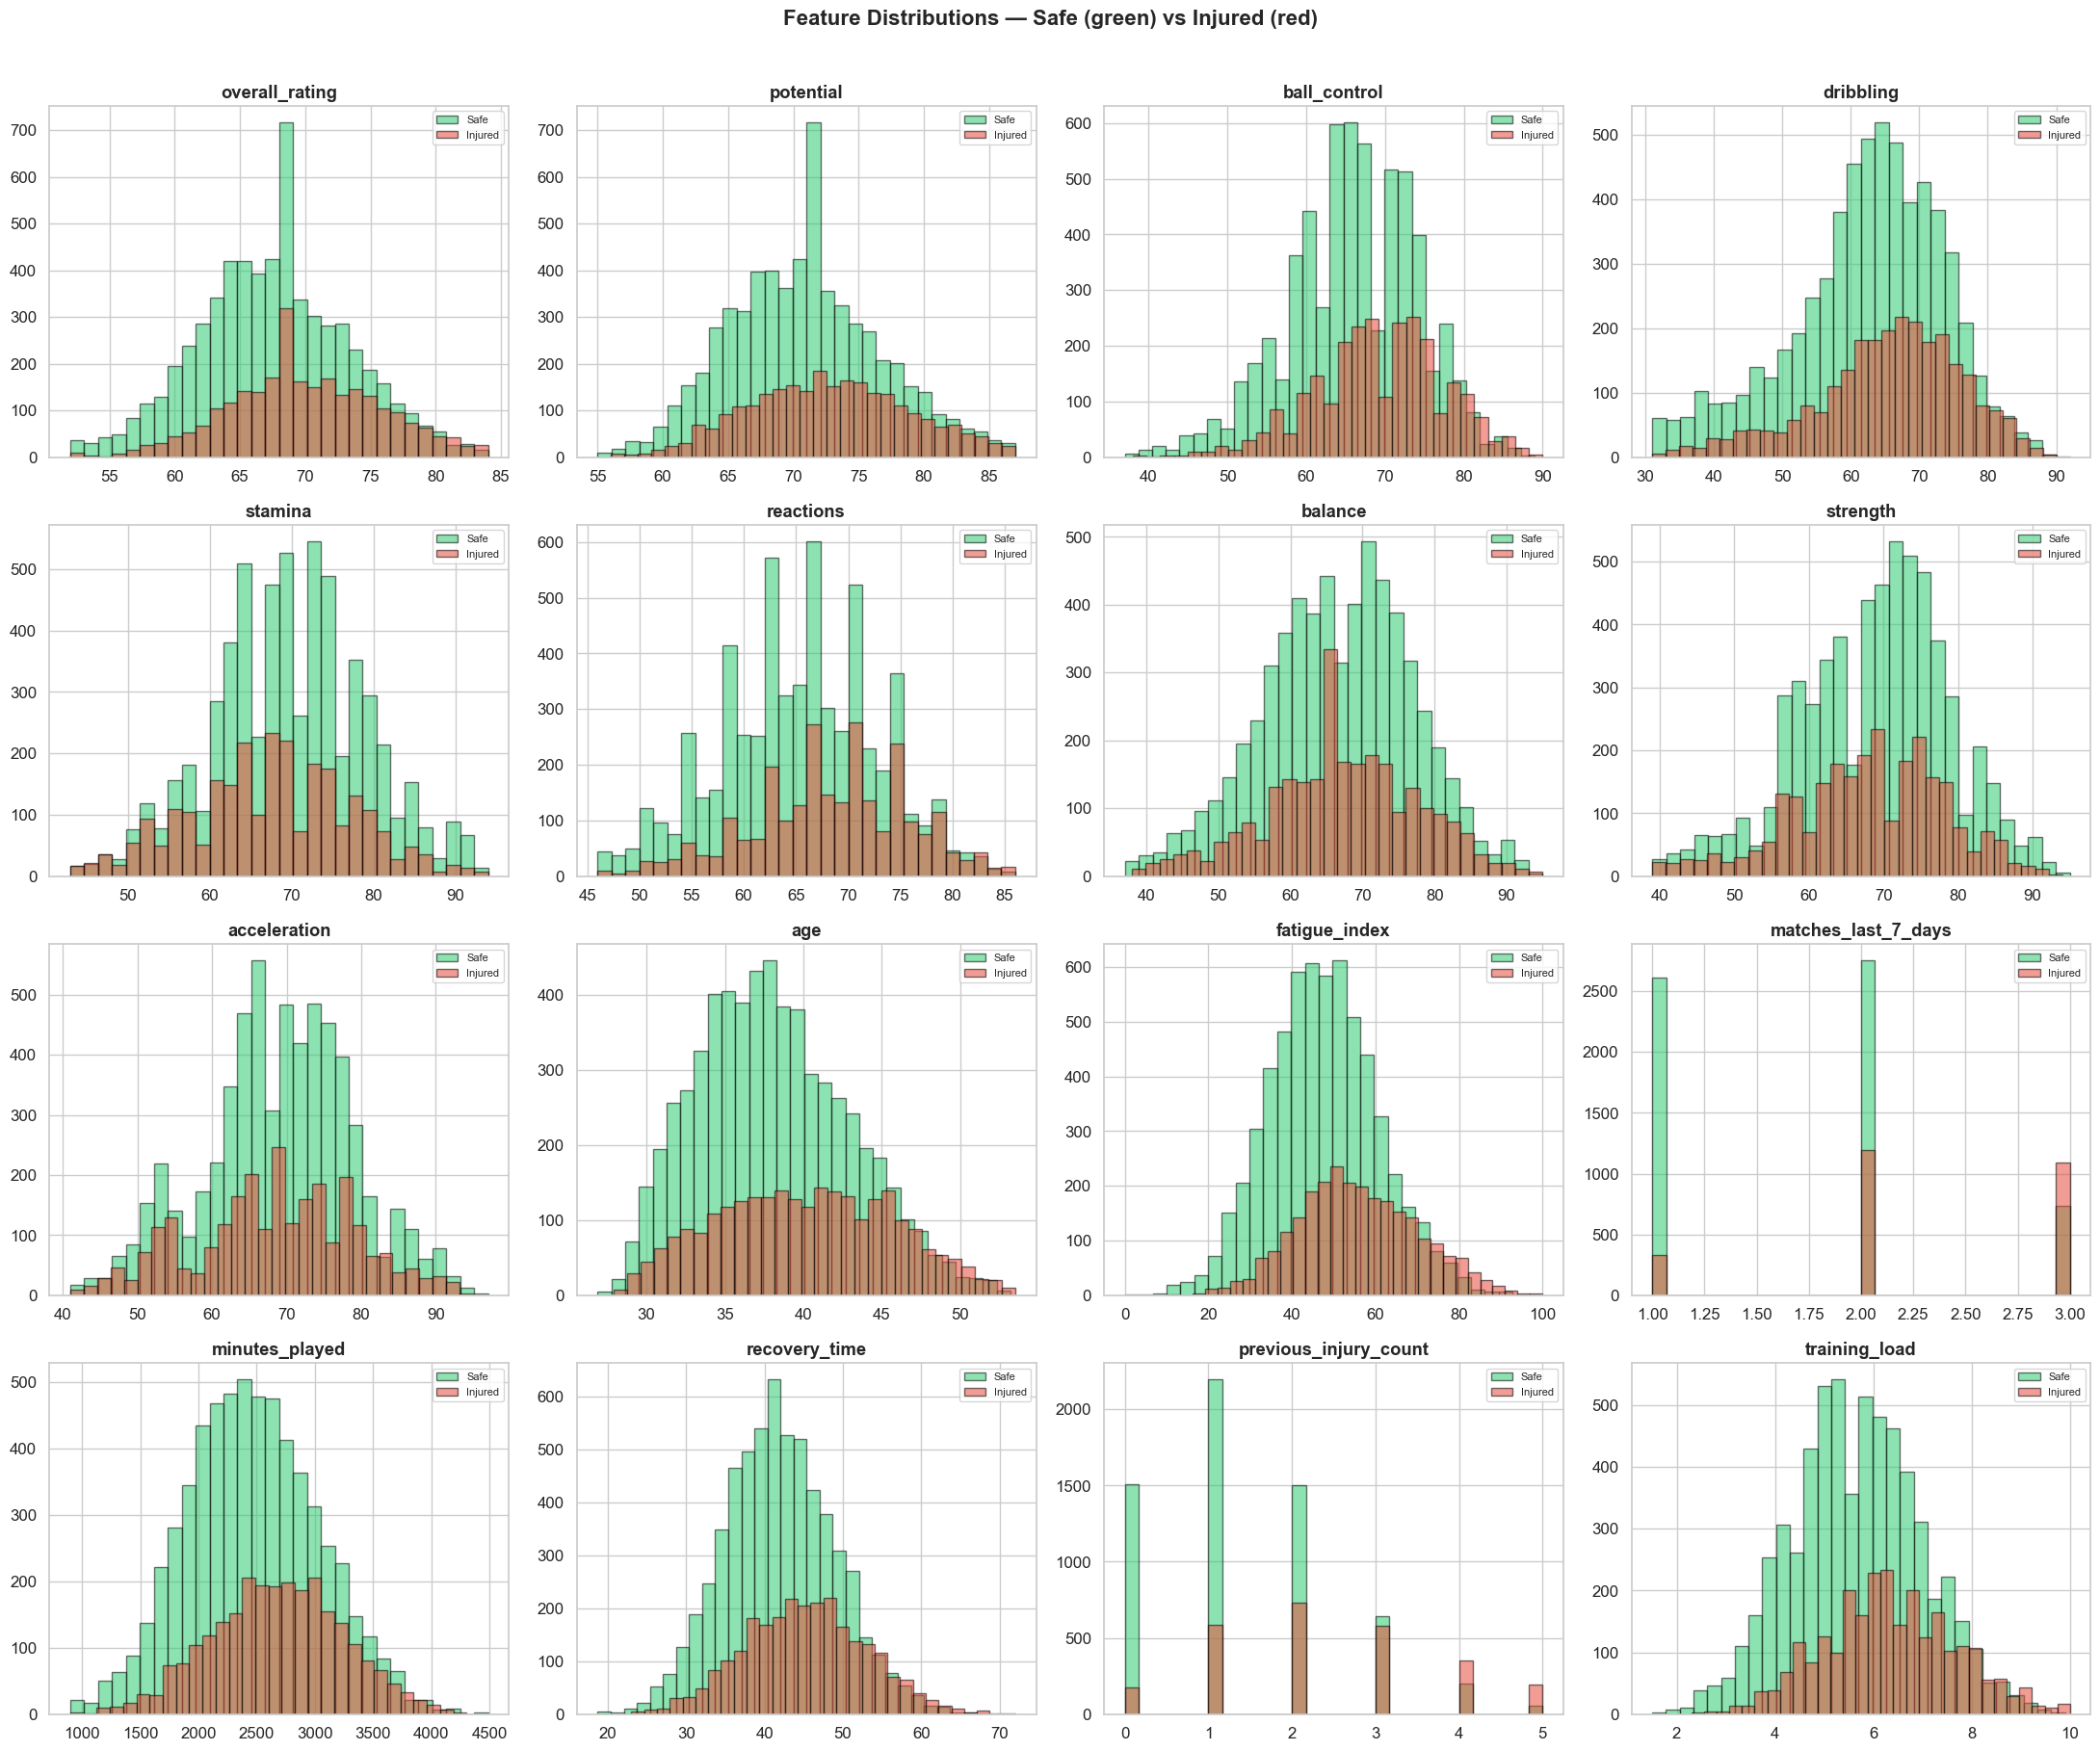

In [10]:
# Histograms overlaid by injury_risk class for all numeric features
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.ravel()

for i, col in enumerate(features):
    for label, color, name in [(0, "#2ecc71", "Safe"), (1, "#e74c3c", "Injured")]:
        subset = df[df["injury_risk"] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.55, color=color, label=name, edgecolor="black")
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions — Safe (green) vs Injured (red)",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Pairplot — Key Injury Features Colored by Target

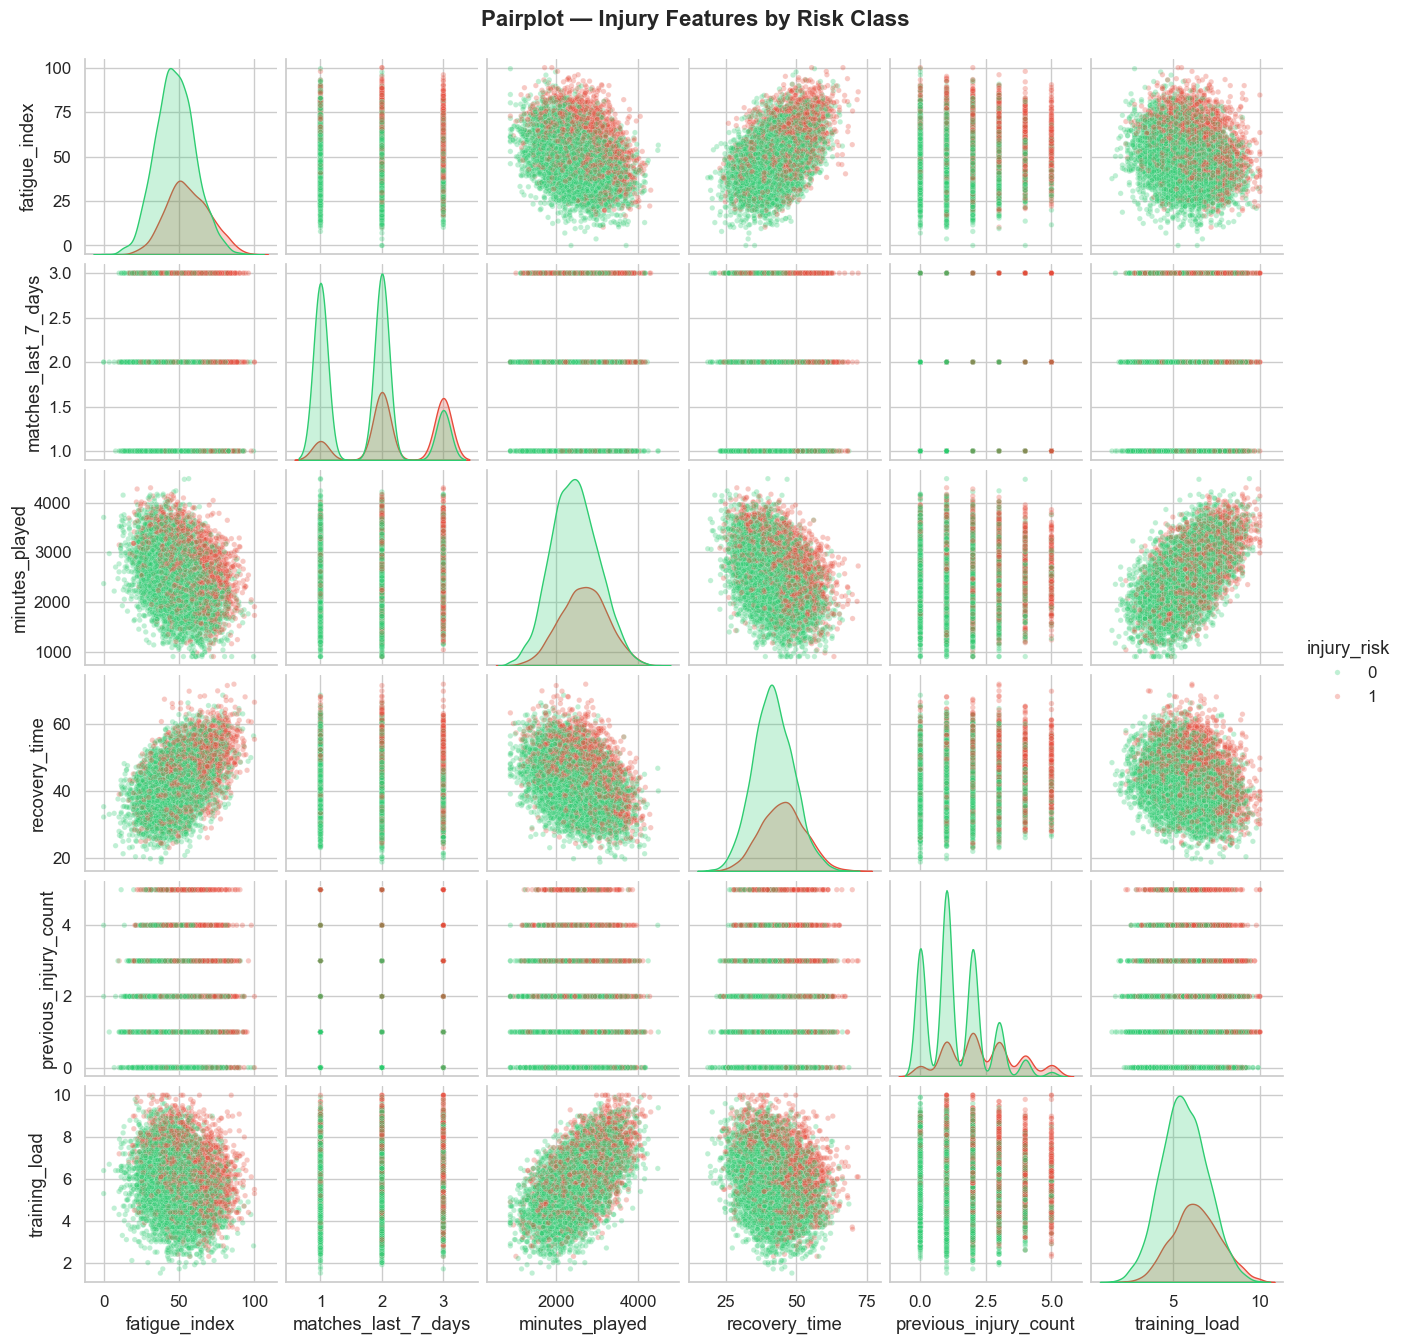

In [11]:
# Pairplot on the 6 synthetic injury features + target
pair_cols = injury_features + ["injury_risk"]
g = sns.pairplot(df[pair_cols], hue="injury_risk", palette=["#2ecc71", "#e74c3c"],
                 diag_kind="kde", plot_kws={"alpha": 0.3, "s": 15}, height=2.2)
g.figure.suptitle("Pairplot — Injury Features by Risk Class", y=1.02, fontsize=16, fontweight="bold")
plt.show()

---
## 10. Z-Score Outlier Detection (|z| > 3)

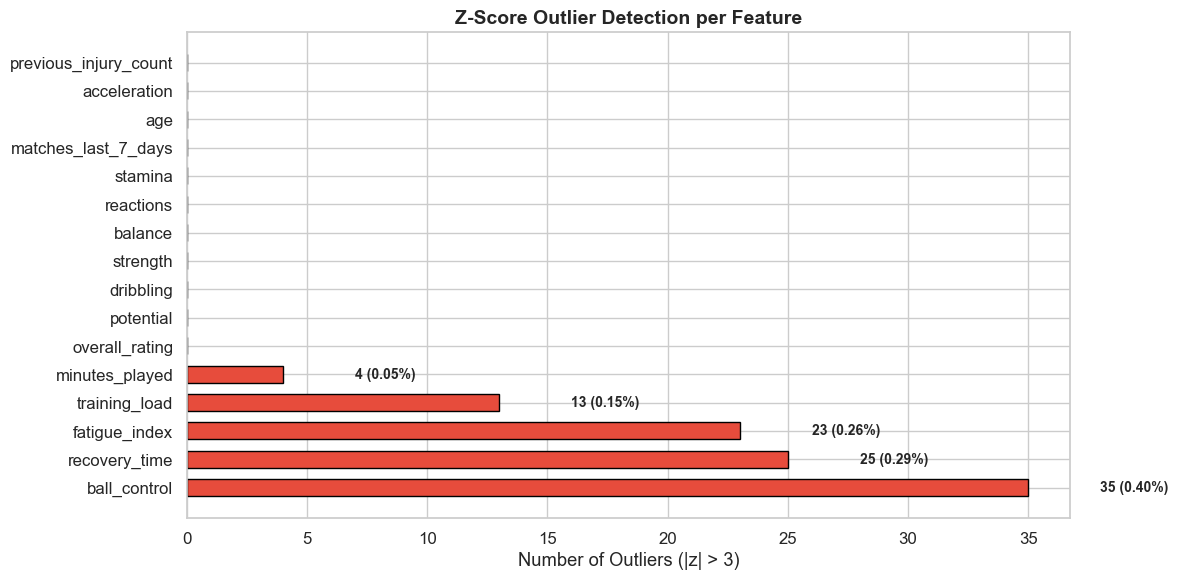


Total data points flagged by Z-score (|z|>3): 100 out of 139424 (0.072%)


In [12]:
# Z-score method: flag values with |z| > 3
from scipy import stats

z_scores = pd.DataFrame(np.abs(stats.zscore(df[features])), columns=features)
z_outlier_counts = (z_scores > 3).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in z_outlier_counts]
bars = ax.barh(z_outlier_counts.index, z_outlier_counts.values, color=colors, edgecolor="black", height=0.6)

for bar, val in zip(bars, z_outlier_counts.values):
    if val > 0:
        ax.text(val + 3, bar.get_y() + bar.get_height()/2,
                f"{val} ({val/len(df)*100:.2f}%)", va="center", fontweight="bold", fontsize=10)

ax.set_xlabel("Number of Outliers (|z| > 3)")
ax.set_title("Z-Score Outlier Detection per Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

total_flagged = (z_scores > 3).sum().sum()
total_points = len(df) * len(features)
print(f"\nTotal data points flagged by Z-score (|z|>3): {total_flagged} "
      f"out of {total_points} ({total_flagged / total_points * 100:.3f}%)")

---
## 11. Feature Importance Analysis for Logistic Regression
Three methods used to rank features:
1. **Pearson Correlation** — linear relationship with target
2. **Mutual Information** — captures non-linear dependencies
3. **Logistic Regression Coefficients** — standardized model weights

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

# Encode categorical work rates
le = LabelEncoder()
df["attacking_work_rate_enc"] = le.fit_transform(df["attacking_work_rate"].str.strip().str.lower())
df["defensive_work_rate_enc"] = le.fit_transform(df["defensive_work_rate"].str.strip().str.lower())

all_features = [c for c in df.select_dtypes(include="number").columns if c != "injury_risk"]
X = df[all_features]
y = df["injury_risk"]

# --- Method 1: Pearson Correlation ---
corr_vals = X.corrwith(y).abs().sort_values(ascending=False)

# --- Method 2: Mutual Information ---
mi_vals = pd.Series(mutual_info_classif(X, y, random_state=42), index=all_features).sort_values(ascending=False)

# --- Method 3: Logistic Regression Coefficients (standardized) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)
lr_coef = pd.Series(np.abs(lr.coef_[0]), index=all_features).sort_values(ascending=False)

# --- Combined Ranking ---
rank_df = pd.DataFrame({
    "Correlation": corr_vals.rank(ascending=False),
    "Mutual_Info": mi_vals.rank(ascending=False),
    "LR_Coeff": lr_coef.rank(ascending=False),
})
rank_df["Avg_Rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("Avg_Rank")
print("Combined Feature Ranking (lower = more important):\n")
rank_df

Combined Feature Ranking (lower = more important):



,Correlation,Mutual_Info,LR_Coeff,Avg_Rank
matches_last_7_days,1.0,2.0,1.0,1.333333
previous_injury_count,2.0,1.0,2.0,1.666667
fatigue_index,3.0,4.0,3.0,3.333333
training_load,4.0,3.0,4.0,3.666667
recovery_time,5.0,6.0,6.0,5.666667
minutes_played,10.0,5.0,5.0,6.666667
overall_rating,6.0,7.0,11.0,8.000000
ball_control,8.0,8.0,8.0,8.000000
dribbling,12.0,9.0,7.0,9.333333
age,7.0,10.0,13.0,10.000000


### 11a. Visual Comparison — 3 Methods Side by Side

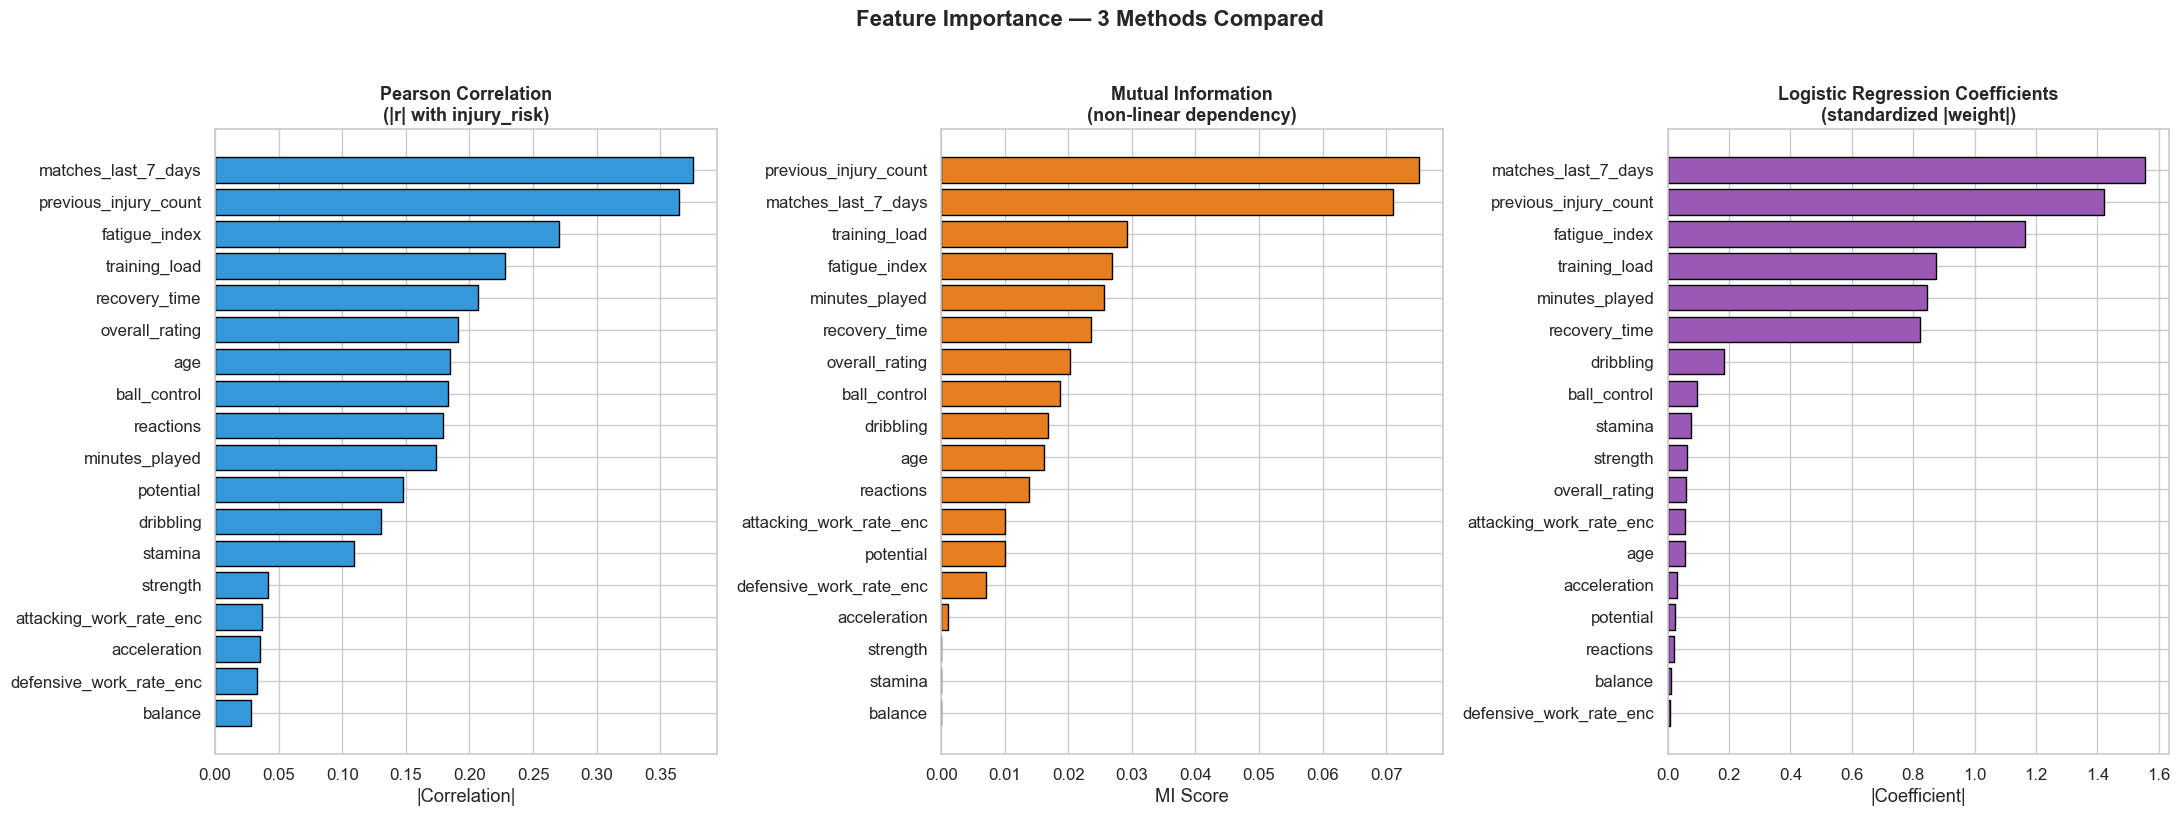

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# --- Plot 1: Pearson Correlation ---
sorted_corr = corr_vals.sort_values()
axes[0].barh(sorted_corr.index, sorted_corr.values, color="#3498db", edgecolor="black")
axes[0].set_title("Pearson Correlation\n(|r| with injury_risk)", fontweight="bold", fontsize=13)
axes[0].set_xlabel("|Correlation|")

# --- Plot 2: Mutual Information ---
sorted_mi = mi_vals.sort_values()
axes[1].barh(sorted_mi.index, sorted_mi.values, color="#e67e22", edgecolor="black")
axes[1].set_title("Mutual Information\n(non-linear dependency)", fontweight="bold", fontsize=13)
axes[1].set_xlabel("MI Score")

# --- Plot 3: Logistic Regression Coefficients ---
sorted_lr = lr_coef.sort_values()
axes[2].barh(sorted_lr.index, sorted_lr.values, color="#9b59b6", edgecolor="black")
axes[2].set_title("Logistic Regression Coefficients\n(standardized |weight|)", fontweight="bold", fontsize=13)
axes[2].set_xlabel("|Coefficient|")

plt.suptitle("Feature Importance — 3 Methods Compared", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 11b. Final Recommended Features for Logistic Regression

Recommended features for Logistic Regression (Avg Rank <= 8):

  1. matches_last_7_days             (Avg Rank: 1.33)
  2. previous_injury_count           (Avg Rank: 1.67)
  3. fatigue_index                   (Avg Rank: 3.33)
  4. training_load                   (Avg Rank: 3.67)
  5. recovery_time                   (Avg Rank: 5.67)
  6. minutes_played                  (Avg Rank: 6.67)
  7. overall_rating                  (Avg Rank: 8.00)
  8. ball_control                    (Avg Rank: 8.00)


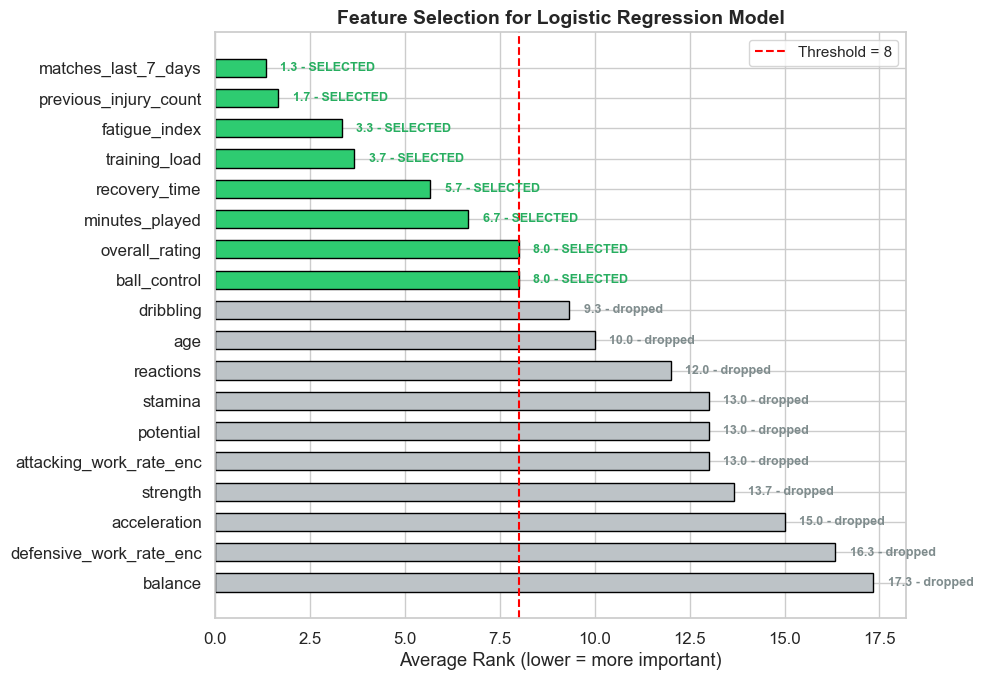


>> Total features selected: 8 out of 18
>> Features to use: ['matches_last_7_days', 'previous_injury_count', 'fatigue_index', 'training_load', 'recovery_time', 'minutes_played', 'overall_rating', 'ball_control']


In [15]:
# Select features with Avg_Rank <= 8 (top performers across all 3 methods)
threshold = 8
selected = rank_df[rank_df["Avg_Rank"] <= threshold].index.tolist()

print(f"Recommended features for Logistic Regression (Avg Rank <= {threshold}):\n")
for i, feat in enumerate(selected, 1):
    avg = rank_df.loc[feat, "Avg_Rank"]
    print(f"  {i}. {feat:<30s}  (Avg Rank: {avg:.2f})")

# Highlight selected vs dropped in a horizontal bar
fig, ax = plt.subplots(figsize=(10, 7))
avg_ranks = rank_df["Avg_Rank"].sort_values(ascending=False)
colors = ["#2ecc71" if f in selected else "#bdc3c7" for f in avg_ranks.index]
ax.barh(avg_ranks.index, avg_ranks.values, color=colors, edgecolor="black", height=0.6)

for bar_idx, (feat, val) in enumerate(avg_ranks.items()):
    label = "SELECTED" if feat in selected else "dropped"
    color = "#27ae60" if feat in selected else "#7f8c8d"
    ax.text(val + 0.2, bar_idx, f"  {val:.1f} - {label}",
            va="center", fontweight="bold", fontsize=9, color=color)

ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1.5, label=f"Threshold = {threshold}")
ax.set_xlabel("Average Rank (lower = more important)")
ax.set_title("Feature Selection for Logistic Regression Model", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n>> Total features selected: {len(selected)} out of {len(all_features)}")
print(f">> Features to use: {selected}")

---
## 12. Feature Dependency on Injury Risk — Model Coefficient Analysis
How much does each feature contribute to the injury prediction decision?

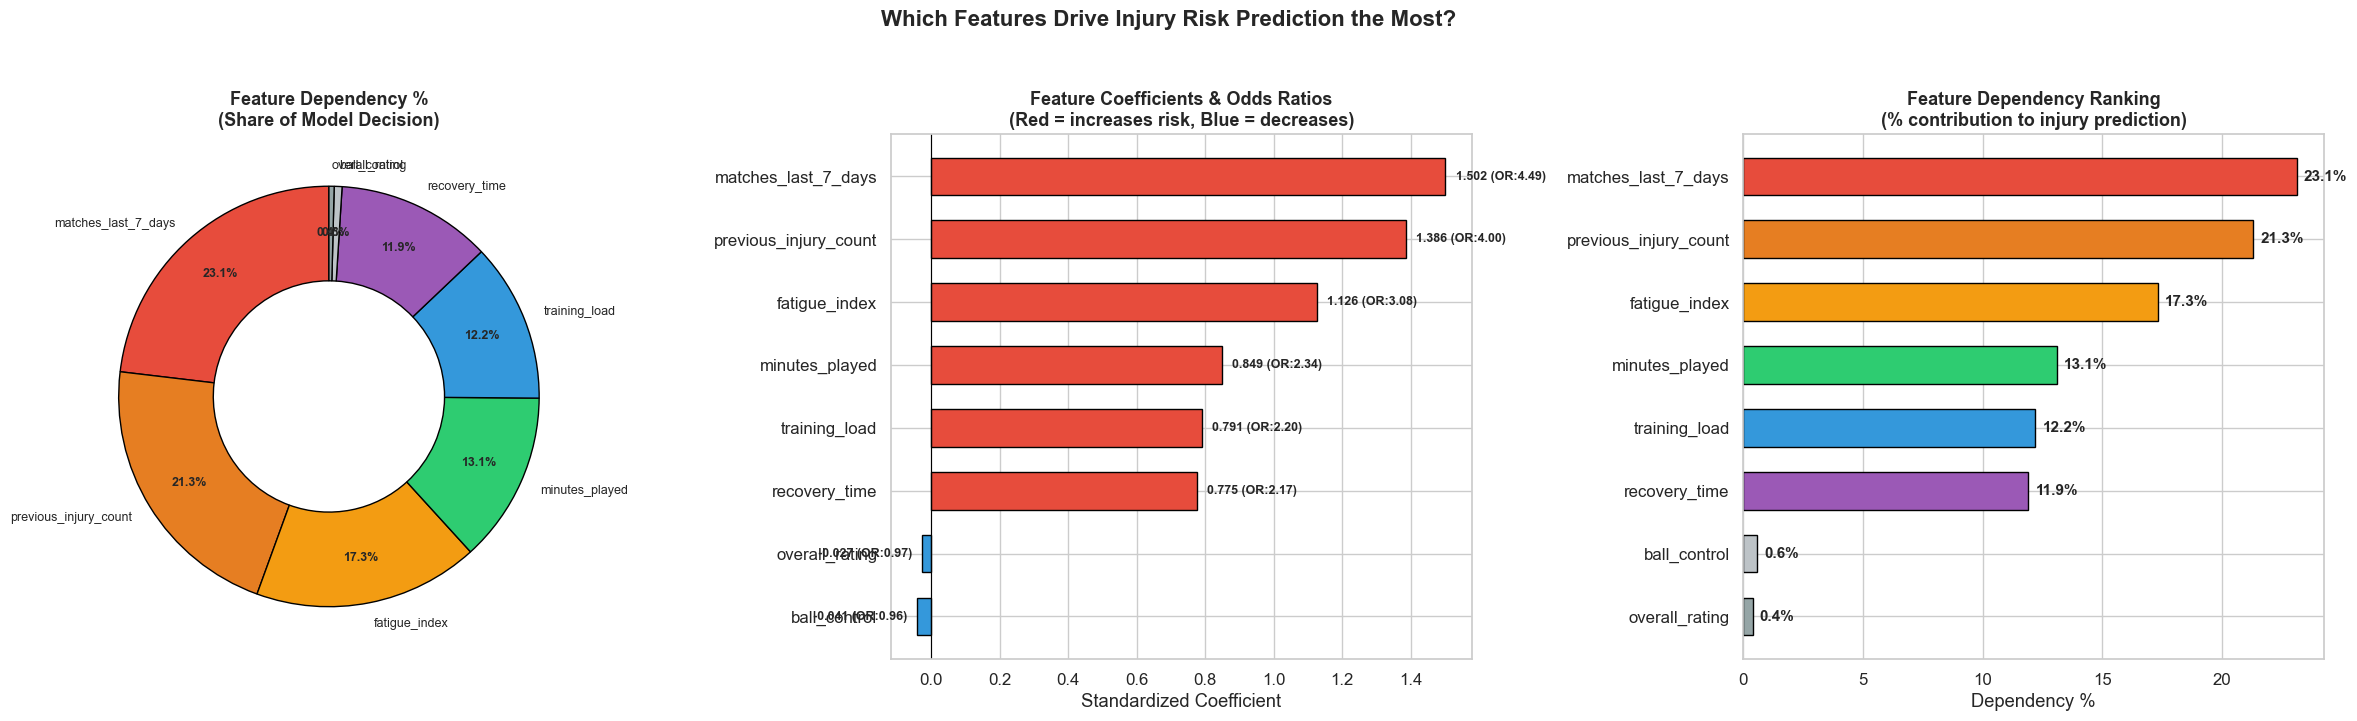


Feature Dependency Table:

              Feature  Coefficient  Odds_Ratio  Dependency %
  matches_last_7_days     1.501522    4.488517          23.1
previous_injury_count     1.386215    3.999684          21.3
        fatigue_index     1.126177    3.083845          17.3
       minutes_played     0.849059    2.337446          13.1
        training_load     0.790578    2.204671          12.2
        recovery_time     0.774792    2.170141          11.9
         ball_control    -0.041230    0.959608           0.6
       overall_rating    -0.026736    0.973618           0.4


In [16]:
from sklearn.model_selection import train_test_split

# Selected 8 important features
selected_features = ["matches_last_7_days", "previous_injury_count", "fatigue_index",
                     "training_load", "recovery_time", "minutes_played",
                     "overall_rating", "ball_control"]

X_sel = df[selected_features]
y_sel = df["injury_risk"]

X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y_sel, test_size=0.2, random_state=42, stratify=y_sel)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr)

# Build results table
dep_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lr_model.coef_[0],
    "Abs_Coefficient": np.abs(lr_model.coef_[0]),
    "Odds_Ratio": np.exp(lr_model.coef_[0]),
}).sort_values("Abs_Coefficient", ascending=False)
dep_df["Dependency %"] = (dep_df["Abs_Coefficient"] / dep_df["Abs_Coefficient"].sum() * 100).round(1)

# ── FIGURE: 3 graphs ──
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- 1. Dependency % Donut Chart ---
colors_donut = ["#e74c3c", "#e67e22", "#f39c12", "#2ecc71", "#3498db", "#9b59b6", "#bdc3c7", "#95a5a6"]
wedges, texts, autotexts = axes[0].pie(
    dep_df["Dependency %"], labels=dep_df["Feature"], colors=colors_donut,
    autopct="%1.1f%%", startangle=90, pctdistance=0.78,
    textprops={"fontsize": 9}, wedgeprops={"edgecolor": "black", "linewidth": 1, "width": 0.45})
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(9)
axes[0].set_title("Feature Dependency %\n(Share of Model Decision)", fontweight="bold", fontsize=13)

# --- 2. Coefficient Bar Chart (signed) ---
dep_sorted = dep_df.sort_values("Coefficient")
bar_colors = ["#e74c3c" if c > 0 else "#3498db" for c in dep_sorted["Coefficient"]]
bars = axes[1].barh(dep_sorted["Feature"], dep_sorted["Coefficient"], color=bar_colors,
                     edgecolor="black", height=0.6)
for bar, val, odds in zip(bars, dep_sorted["Coefficient"], dep_sorted["Odds_Ratio"]):
    offset = 0.03 if val >= 0 else -0.03
    ha = "left" if val >= 0 else "right"
    axes[1].text(val + offset, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f} (OR:{odds:.2f})", va="center", ha=ha, fontweight="bold", fontsize=9)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_xlabel("Standardized Coefficient")
axes[1].set_title("Feature Coefficients & Odds Ratios\n(Red = increases risk, Blue = decreases)",
                   fontweight="bold", fontsize=13)

# --- 3. Dependency % Horizontal Bar (ranked) ---
dep_rank = dep_df.sort_values("Dependency %", ascending=True)
bars3 = axes[2].barh(dep_rank["Feature"], dep_rank["Dependency %"],
                      color=colors_donut[:len(dep_rank)][::-1], edgecolor="black", height=0.6)
for bar, pct in zip(bars3, dep_rank["Dependency %"]):
    axes[2].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{pct}%", va="center", fontweight="bold", fontsize=11)
axes[2].set_xlabel("Dependency %")
axes[2].set_title("Feature Dependency Ranking\n(% contribution to injury prediction)",
                   fontweight="bold", fontsize=13)

plt.suptitle("Which Features Drive Injury Risk Prediction the Most?",
             fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Print table
print("\nFeature Dependency Table:\n")
print(dep_df[["Feature", "Coefficient", "Odds_Ratio", "Dependency %"]].to_string(index=False))